# Weekly Hospitalization Demand Forecasting

This notebook uses the CDC RESP-NET COVID-NET overall observed weekly hospitalization rate as a complementary inpatient-demand indicator. It is not a row-level extension of the CMS hospital–DRG dataset. Source: [CDC RESP-NET Rates and Clinical Data](https://data.cdc.gov/Public-Health-Surveillance/RESP-NET-Rates-and-Clinical-Data/kvib-3txy).

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.forecasting import (
    load_resp_net_data, prepare_weekly_series, split_series,
    evaluate_models, forecast_with_selected_model
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 14})

## 1. Source filtering and time-series validation

The modeling series is filtered to COVID-NET, overall age/race/sex/site, weekly rate, rate per 100,000, and observed values. Cumulative rates are excluded because they reset by surveillance season.

In [2]:
raw_data = load_resp_net_data()
weekly_data = prepare_weekly_series(raw_data)
date_gaps = weekly_data['Week_Ending_Date'].diff().dropna()
validation = pd.Series({
    'Raw source rows': len(raw_data),
    'Modeling weeks': len(weekly_data),
    'Unique dates': weekly_data['Week_Ending_Date'].nunique(),
    'Duplicate dates': weekly_data['Week_Ending_Date'].duplicated().sum(),
    'Missing rates': weekly_data['Hospitalization_Rate_Per_100k'].isna().sum(),
    'Non-seven-day gaps': date_gaps.ne(pd.Timedelta(days=7)).sum(),
    'Minimum date': weekly_data['Week_Ending_Date'].min(),
    'Maximum date': weekly_data['Week_Ending_Date'].max(),
})
validation.to_frame('Value')

,Value
Raw source rows,121988
Modeling weeks,334
Unique dates,334
Duplicate dates,0
Missing rates,0
Non-seven-day gaps,0
Minimum date,2020-03-07 00:00:00
Maximum date,2026-07-25 00:00:00


**Impact:** A continuous Saturday-ending weekly series supports seasonal lags and time-based validation without interpolation or fabricated periods.

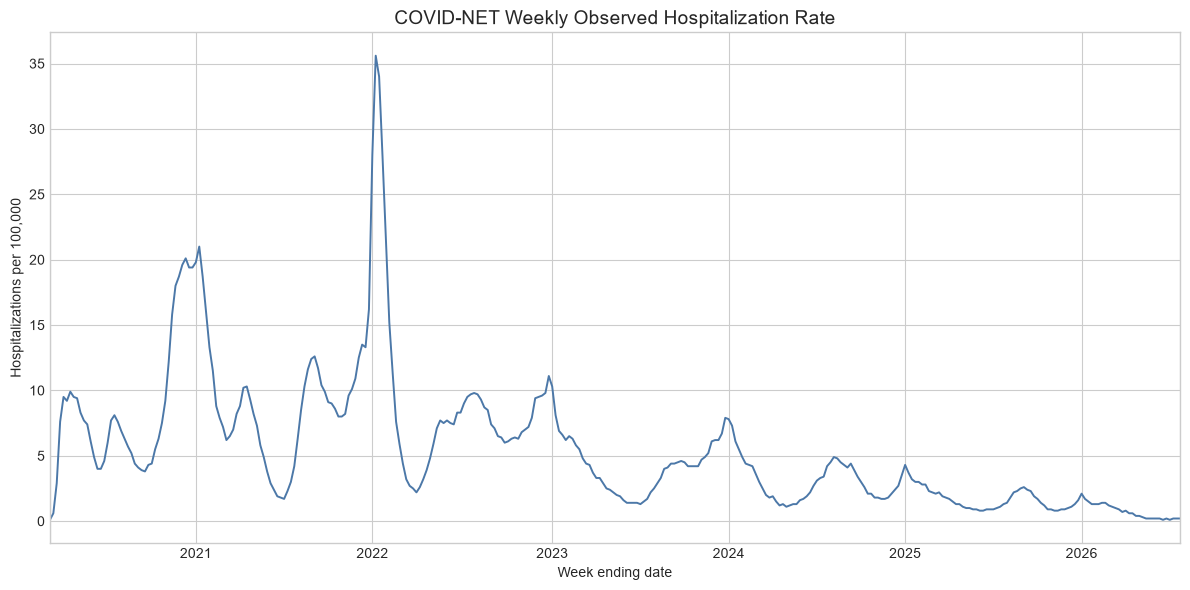

In [3]:
ax = weekly_data.plot(
    x='Week_Ending_Date', y='Hospitalization_Rate_Per_100k',
    color='#4C78A8', linewidth=1.4, legend=False
)
ax.set(title='COVID-NET Weekly Observed Hospitalization Rate', xlabel='Week ending date', ylabel='Hospitalizations per 100,000')
plt.tight_layout(); plt.show()

**Interpretation:** The early-pandemic peaks and later lower-rate regime show structural change. This limits the usefulness of fitting one global trend or assuming historical seasonal magnitude remains stable.

## 2. Chronological train/test split

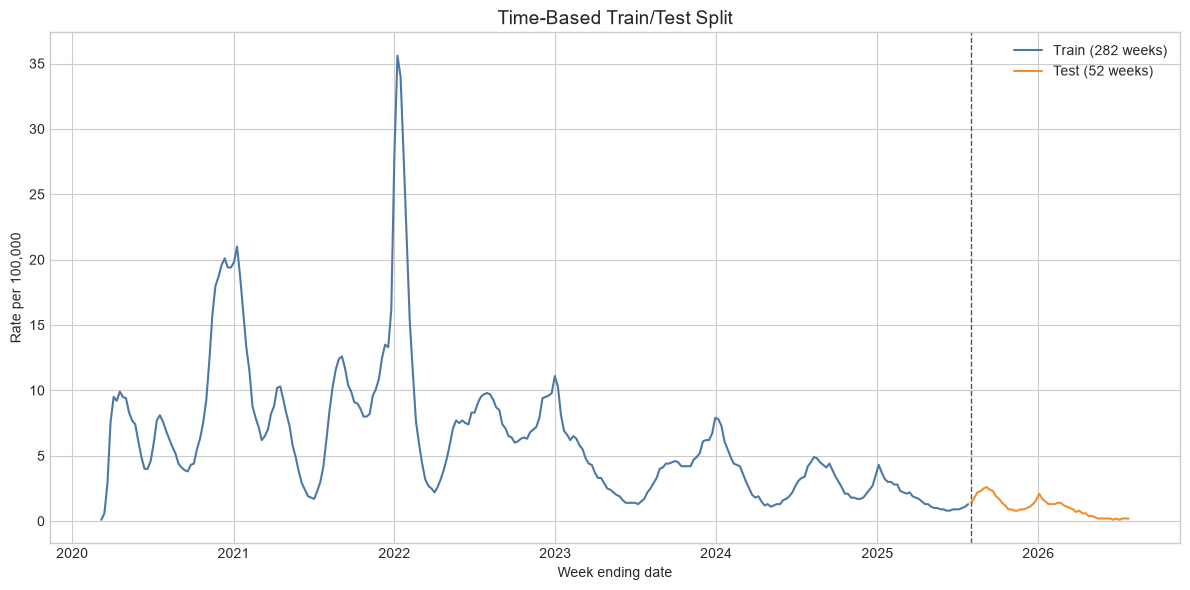

In [4]:
train, test = split_series(weekly_data, test_weeks=52)
plt.plot(train.index, train, label=f'Train ({len(train)} weeks)', color='#4C78A8')
plt.plot(test.index, test, label=f'Test ({len(test)} weeks)', color='#F28E2B')
plt.axvline(test.index.min(), color='#555555', linestyle='--', linewidth=1)
plt.title('Time-Based Train/Test Split'); plt.xlabel('Week ending date'); plt.ylabel('Rate per 100,000')
plt.legend(); plt.tight_layout(); plt.show()

**Why:** The final 52 weeks simulate genuinely unseen future data. Random splitting would leak future behavior into training and overstate forecast performance.

## 3. Baseline and statistical model evaluation

In [5]:
metrics, test_predictions, predictions = evaluate_models(train, test)
metrics.style.format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'MAPE_Pct': '{:.1f}%'})

,Model,MAE,RMSE,MAPE_Pct
0,AutoReg_Recent_156_Weeks,0.276,0.350,38.8%
1,Linear_Trend,0.346,0.451,34.8%
2,Moving_Average_4_Week,0.582,0.705,148.0%
3,Naive_Last_Value,0.613,0.740,181.8%
4,Seasonal_Naive_52_Week,1.267,1.400,188.9%
5,Holt_Winters_Additive,1.548,2.402,137.9%


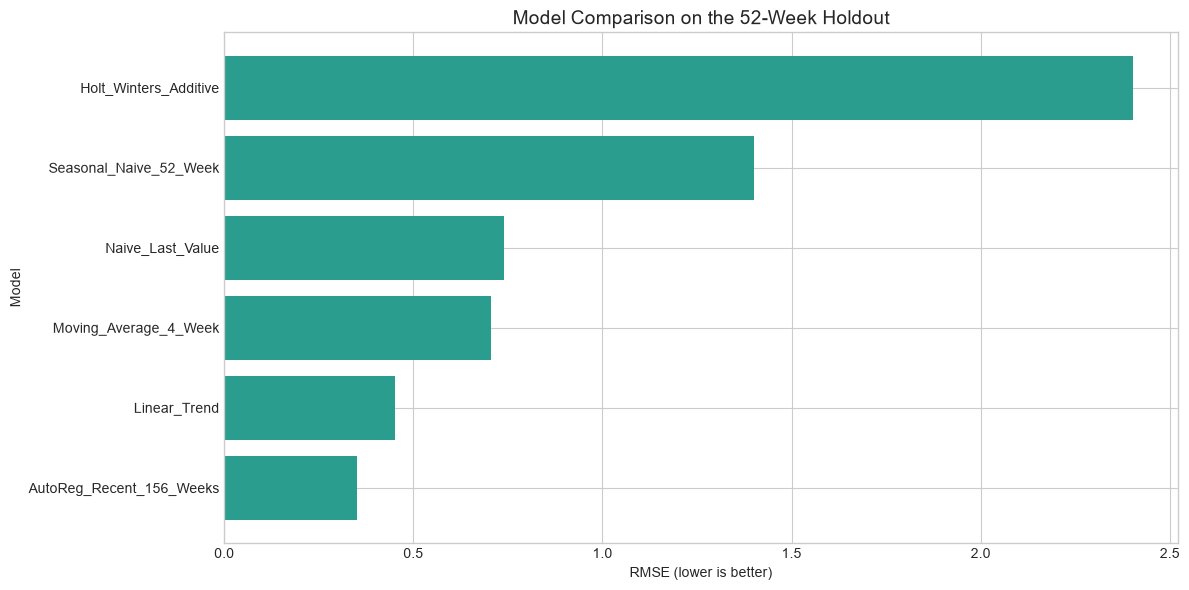

In [6]:
plot_metrics = metrics.sort_values('RMSE', ascending=True)
plt.barh(plot_metrics['Model'], plot_metrics['RMSE'], color='#2A9D8F')
plt.title('Model Comparison on the 52-Week Holdout'); plt.xlabel('RMSE (lower is better)'); plt.ylabel('Model')
plt.tight_layout(); plt.show()

**Interpretation:** The recent 156-week autoregression has the lowest MAE and RMSE. It uses lags 1–4 for short-term persistence and lag 52 for annual recurrence. Linear trend has slightly lower MAPE, but RMSE is the primary selection metric because larger rate errors matter operationally.

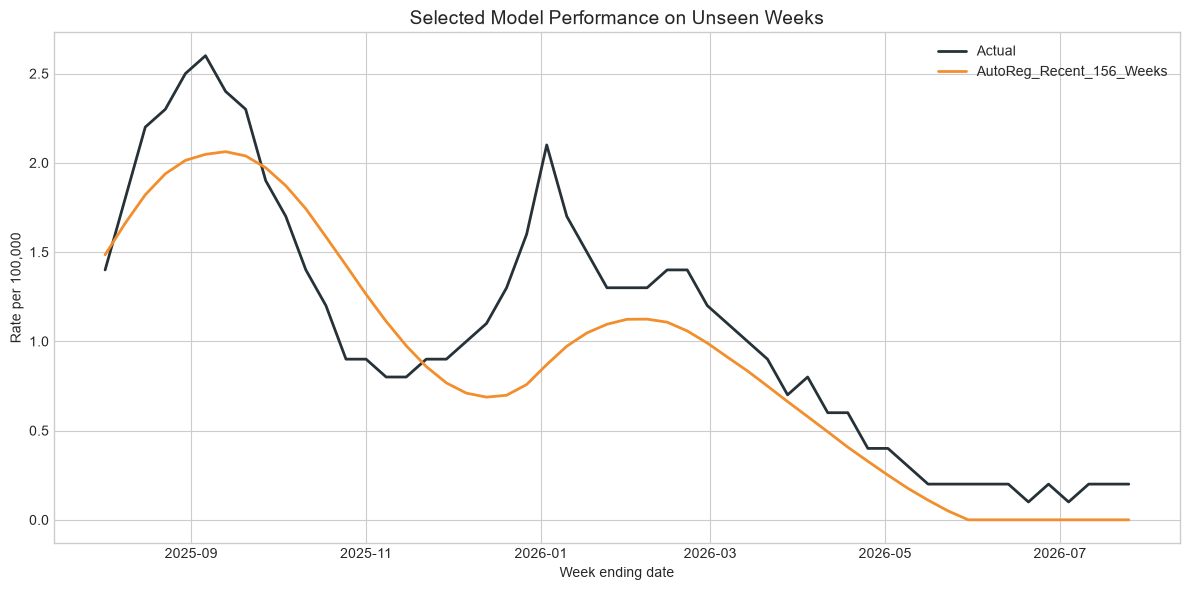

In [7]:
selected_model = metrics.iloc[0]['Model']
plt.plot(test.index, test, label='Actual', color='#263238', linewidth=2)
plt.plot(test.index, predictions[selected_model], label=selected_model, color='#F28E2B', linewidth=2)
plt.title('Selected Model Performance on Unseen Weeks'); plt.xlabel('Week ending date'); plt.ylabel('Rate per 100,000')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Twelve-week forecast

In [8]:
full_series = weekly_data.set_index('Week_Ending_Date')['Hospitalization_Rate_Per_100k'].astype(float).asfreq('W-SAT')
forecast = forecast_with_selected_model(
    full_series, selected_model, test, predictions[selected_model], horizon=12
)
forecast.style.format({
    'Forecast_Rate_Per_100k': '{:.3f}',
    'Lower_95_Pct_Approx': '{:.3f}',
    'Upper_95_Pct_Approx': '{:.3f}',
})

,Week_Ending_Date,Forecast_Rate_Per_100k,Lower_95_Pct_Approx,Upper_95_Pct_Approx,Selected_Model
0,2026-08-01 00:00:00,0.199,0.000,0.790,AutoReg_Recent_156_Weeks
1,2026-08-08 00:00:00,0.212,0.000,0.803,AutoReg_Recent_156_Weeks
2,2026-08-15 00:00:00,0.246,0.000,0.837,AutoReg_Recent_156_Weeks
3,2026-08-22 00:00:00,0.286,0.000,0.877,AutoReg_Recent_156_Weeks
4,2026-08-29 00:00:00,0.334,0.000,0.925,AutoReg_Recent_156_Weeks
5,2026-09-05 00:00:00,0.381,0.000,0.973,AutoReg_Recent_156_Weeks
6,2026-09-12 00:00:00,0.412,0.000,1.003,AutoReg_Recent_156_Weeks
7,2026-09-19 00:00:00,0.425,0.000,1.017,AutoReg_Recent_156_Weeks
8,2026-09-26 00:00:00,0.408,0.000,0.999,AutoReg_Recent_156_Weeks
9,2026-10-03 00:00:00,0.367,0.000,0.958,AutoReg_Recent_156_Weeks


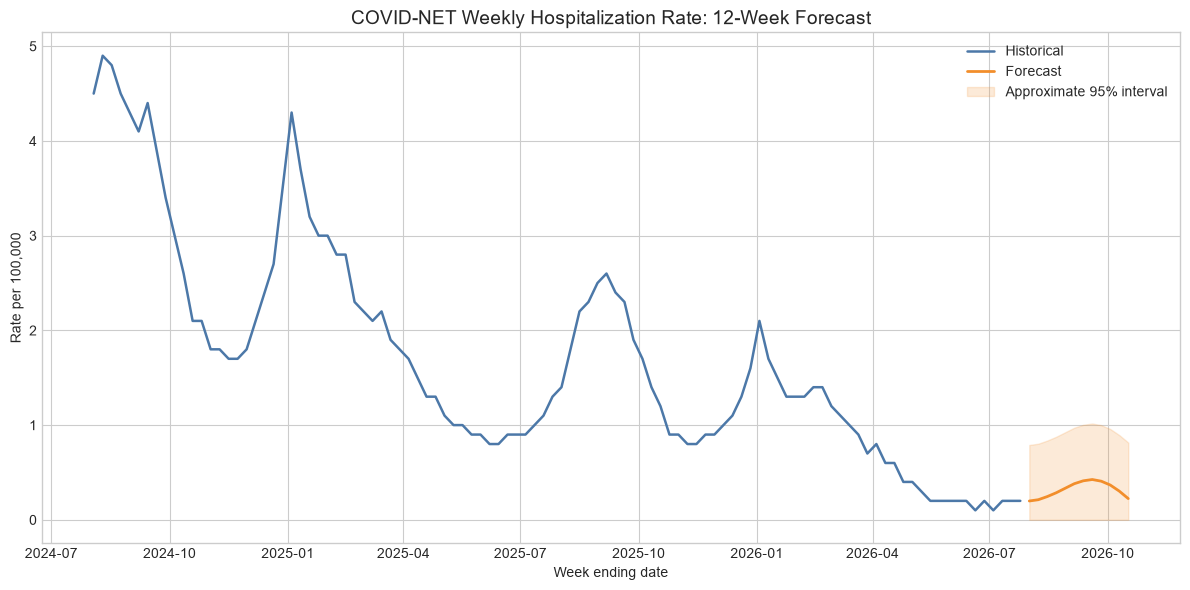

In [9]:
recent = full_series.iloc[-104:]
plt.plot(recent.index, recent, label='Historical', color='#4C78A8', linewidth=1.8)
plt.plot(forecast['Week_Ending_Date'], forecast['Forecast_Rate_Per_100k'], label='Forecast', color='#F28E2B', linewidth=2)
plt.fill_between(
    forecast['Week_Ending_Date'], forecast['Lower_95_Pct_Approx'], forecast['Upper_95_Pct_Approx'],
    color='#F28E2B', alpha=.18, label='Approximate 95% interval'
)
plt.title('COVID-NET Weekly Hospitalization Rate: 12-Week Forecast'); plt.xlabel('Week ending date'); plt.ylabel('Rate per 100,000')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Business interpretation and limitations

- The point forecast rises modestly through mid-September 2026 and then declines by mid-October.
- The approximate interval is wide and includes zero, so the direction and magnitude are uncertain.
- Management should monitor weekly respiratory admissions and retain flexible staffing or bed-capacity options rather than commit resources solely from this forecast.
- RESP-NET covers surveillance catchment areas and is not the same population as the CMS hospital–DRG dataset.
- Rates are preliminary and can be revised. Early-pandemic structural change reduces long-run stability.
- The interval is an empirical residual-based approximation, not a formal model-specific probabilistic interval.